In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
# from sklearn.preprocessing import PCA

In [2]:
t = pd.read_csv('t_clean.csv', parse_dates=['CREATED_DATE_TRANS', 'datetime', 'date'])
t.info()

<class 'pandas.DataFrame'>
RangeIndex: 638742 entries, 0 to 638741
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CURRENCY            638742 non-null  str           
 1   AMOUNT              638742 non-null  int64         
 2   STATE               638742 non-null  str           
 3   CREATED_DATE_TRANS  638742 non-null  datetime64[us]
 4   MERCHANT_CATEGORY   638742 non-null  str           
 5   MERCHANT_COUNTRY    638512 non-null  str           
 6   ENTRY_METHOD        638742 non-null  str           
 7   TYPE                638742 non-null  str           
 8   SOURCE              638742 non-null  str           
 9   TRANS_ID            638742 non-null  str           
 10  AMOUNT_USD          586125 non-null  float64       
 11  datetime            638742 non-null  datetime64[us]
 12  date                638742 non-null  datetime64[us]
 13  ID                  638742 non-null  str

In [3]:
t = t.sort_values(['ID', 'datetime'])

In [4]:
u = pd.read_csv('u_clean.csv', parse_dates=['CREATED_DATE_ACC'])
u.info()

<class 'pandas.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       9944 non-null   str           
 1   HAS_EMAIL                9944 non-null   int64         
 2   PHONE_COUNTRY            9944 non-null   str           
 3   IS_FRAUDSTER             9944 non-null   bool          
 4   TERMS_VERSION            9944 non-null   str           
 5   CREATED_DATE_ACC         9944 non-null   datetime64[us]
 6   COUNTRY                  9944 non-null   str           
 7   BIRTH_YEAR               9944 non-null   int64         
 8   KYC                      9944 non-null   str           
 9   FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64         
dtypes: bool(1), datetime64[us](1), int64(3), str(5)
memory usage: 709.0 KB


In [5]:
# ideally we want to work with AMOUNT_USD, but it has missing values, let's for now dropna, and then come back to this issue 
# probably smth with convertion 
sum(t.loc[t.AMOUNT_USD.isna(), ['IS_FRAUDSTER', 'ID']].drop_duplicates()['IS_FRAUDSTER'])
# 8 less fraudsters in training


8

### Amount USD features

In [6]:
p95 = t.AMOUNT_USD.quantile(.95)
amt_usd_features = (t
    .dropna()
    .groupby('ID')
    .agg(   #central tendency measures
            amt_mean = ('AMOUNT_USD', 'mean'),
            amt_median=('AMOUNT_USD', 'median'),
            amt_std=('AMOUNT_USD', 'std'),
            amt_min=('AMOUNT_USD', 'min'),
            amt_max=('AMOUNT_USD', 'max'),
            # amt_cv = std/mean (coefficient of variation — flags erratic spenders)
            
            # shape
            amt_skew=('AMOUNT_USD', 'skew'), #frauds skew harder given the bimodal pattern in the histogram from EDA
            pct_above_p95 = ('AMOUNT_USD', lambda x: (x>p95).mean()), #very high: fraction of trans > global 95 percentile
            pct_micro_trx = ('AMOUNT_USD', lambda x: (x<5).mean()),
            # max_to_median_ratio = amt_max / amt_median
            
            trx_count = ('AMOUNT_USD', 'count')
            # zscore_vs_user_history = (current amount − running mean) / running std
            # is_new_max - flag if a transaction exceeds everything seen before for that user
         )
    )



### Time features

In [7]:
# t['dt_lag'] = t.groupby(['ID'])['datetime'].shift(1)
# time between transaction could be extremely important for understanding human behaviour
t['gap_hours'] = t.groupby('ID')['datetime'].diff().dt.total_seconds()/3600

In [8]:
# night activity
t['hour_of_day'] = t.datetime.dt.hour
t['is_night'] = t['hour_of_day'].between(0,5).astype(int)

In [9]:
# weekend activity
t['is_weekend'] = t['datetime'].dt.day_of_week.isin([5,6]).astype(int)

In [10]:
t.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE_TRANS',
       'MERCHANT_CATEGORY', 'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'TYPE',
       'SOURCE', 'TRANS_ID', 'AMOUNT_USD', 'datetime', 'date', 'ID',
       'IS_FRAUDSTER', 'IS_CRYPTO', 'gap_hours', 'hour_of_day', 'is_night',
       'is_weekend'],
      dtype='str')

In [11]:
# rolling time aggregates per user (amount trans in hour, day, week)
t['txn_count_1h'] = t.groupby('ID', sort=True).rolling('1h', on='datetime')['TRANS_ID'].count().values
t['txn_count_24h'] = t.groupby('ID', sort=True).rolling('24h', on='datetime')['TRANS_ID'].count().values
t['txn_count_7d'] = t.groupby('ID', sort=True).rolling('7D', on='datetime')['TRANS_ID'].count().values

In [12]:
u.columns

Index(['ID', 'HAS_EMAIL', 'PHONE_COUNTRY', 'IS_FRAUDSTER', 'TERMS_VERSION',
       'CREATED_DATE_ACC', 'COUNTRY', 'BIRTH_YEAR', 'KYC',
       'FAILED_SIGN_IN_ATTEMPTS'],
      dtype='str')

In [13]:
# let's check the time between creating the account and first/last transactions
t = t.merge(u[['ID', 'CREATED_DATE_ACC']], on='ID')

In [14]:
t.CREATED_DATE_ACC = pd.to_datetime(t.CREATED_DATE_ACC.astype(str).str.split('.', regex=False).str[0])

In [15]:
t['account_age_days'] = (t['datetime'] - t['CREATED_DATE_ACC']).dt.total_seconds() / 86400 # =3600*24

In [16]:
t.columns

Index(['CURRENCY', 'AMOUNT', 'STATE', 'CREATED_DATE_TRANS',
       'MERCHANT_CATEGORY', 'MERCHANT_COUNTRY', 'ENTRY_METHOD', 'TYPE',
       'SOURCE', 'TRANS_ID', 'AMOUNT_USD', 'datetime', 'date', 'ID',
       'IS_FRAUDSTER', 'IS_CRYPTO', 'gap_hours', 'hour_of_day', 'is_night',
       'is_weekend', 'txn_count_1h', 'txn_count_24h', 'txn_count_7d',
       'CREATED_DATE_ACC', 'account_age_days'],
      dtype='str')

In [17]:
trx_time_features = (t
    .groupby('ID')
    .agg(
        #  Inter-transaction timing
         mean_gap_hours = ('gap_hours', 'mean'),
         median_gap_hours = ('gap_hours', 'median'),
         std_gap_hours = ('gap_hours', 'std'),
         min_gap_hours = ('gap_hours', 'min'),
         
        #  Velocity
         max_txn_in_1h=('txn_count_1h', 'max'),
         max_txn_in_day=('txn_count_24h', 'max'),
         
        #  time to first/last acc activity:
        days_to_first_txn=('account_age_days', 'min'),
        days_to_last_txn=('account_age_days', 'last'),
        last_txn_datetime=('datetime', 'max'),
        first_txn_date=('date','min'),
        
        # time habits: behaviour at night, weekend
        pct_night_txn=('is_night','mean'),
        pct_weekend_txn=('is_weekend', 'mean'),
        std_hour_of_day=('hour_of_day', 'std'), #variability, are there any hours habits?
        
        n_days_active=('date','nunique')
        
    )
    )

In [18]:
trx_time_features['min_gap_seconds'] = trx_time_features['min_gap_hours'] * 3600

trx_time_features['txn_span_days']= (trx_time_features['last_txn_datetime'] - trx_time_features['first_txn_date']).dt.total_seconds()/(3600*24)
trx_time_features['pct_days_active'] = trx_time_features['n_days_active'] / trx_time_features['txn_span_days']

In [19]:
observation_end = t['datetime'].max()
trx_time_features['days_since_last_txn'] = (observation_end - trx_time_features['last_txn_datetime']).dt.total_seconds() / 86400
# trx_time_features['gap_cv'] = trx_time_features['std_gap_hours'] / trx_time_features['mean_gap_hours']



In [20]:
u.columns

Index(['ID', 'HAS_EMAIL', 'PHONE_COUNTRY', 'IS_FRAUDSTER', 'TERMS_VERSION',
       'CREATED_DATE_ACC', 'COUNTRY', 'BIRTH_YEAR', 'KYC',
       'FAILED_SIGN_IN_ATTEMPTS'],
      dtype='str')

### Other native transactional features

In [21]:
# 1. Transaction precess type
user_state = pd.crosstab(t.ID, t.STATE, normalize='index').reset_index()
user_state.head()

STATE,ID,CANCELLED,COMPLETED,DECLINED,FAILED,PENDING,RECORDED,REVERTED
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,0.0,0.750000,0.000000,0.0,0.0,0.0,0.250000
1,001032e0-8071-4baf-95b9-e50214665c2e,0.0,0.861111,0.055556,0.0,0.0,0.0,0.083333
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,0.0,0.714286,0.142857,0.0,0.0,0.0,0.142857
3,001926be-3245-43fa-86dd-b40ee160b6f9,0.0,0.905512,0.051181,0.0,0.0,0.0,0.043307
4,001cc034-5730-47c6-a70c-25f42249c9ee,0.0,0.750000,0.000000,0.0,0.0,0.0,0.250000


In [22]:
# 2. Transaction type distribution
user_type = pd.crosstab(t.ID, t.TYPE, normalize='index').reset_index()
user_type.head()


TYPE,ID,ATM,BANK_TRANSFER,CARD_PAYMENT,P2P,TOPUP
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,0.000000,0.0625,0.500000,0.125000,0.312500
1,001032e0-8071-4baf-95b9-e50214665c2e,0.055556,0.0000,0.638889,0.000000,0.305556
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,0.000000,0.0000,0.428571,0.000000,0.571429
3,001926be-3245-43fa-86dd-b40ee160b6f9,0.078740,0.0000,0.629921,0.059055,0.232283
4,001cc034-5730-47c6-a70c-25f42249c9ee,0.000000,0.5000,0.000000,0.000000,0.500000


In [23]:
# 3. Entry method distribution
user_entry_method = pd.crosstab(t.ID, t.ENTRY_METHOD, normalize='index').reset_index()
user_entry_method.head(3)

ENTRY_METHOD,ID,chip,cont,mags,manu,mcon,misc
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,0.000000,0.500000,0.000000,0.000000,0.0,0.500000
1,001032e0-8071-4baf-95b9-e50214665c2e,0.333333,0.166667,0.138889,0.055556,0.0,0.305556
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,0.142857,0.000000,0.000000,0.285714,0.0,0.571429


In [24]:
# Combine all features +  user table:
features = (
    amt_usd_features
        .merge(trx_time_features, on='ID', how='inner')
        .merge(user_state, on='ID', how='inner')
        .merge(user_entry_method, on='ID', how='inner')
        .merge(user_type, on='ID', how='inner')
        .merge(u, on='ID',  how='left')
        # .drop(columns=['CREATED_DATE_ACC', 'first_txn_date', 'last_txn_datetime'])
        # .drop(columns='ID')
)

features.shape

(7186, 55)

### additional features + encoding

In [25]:
features['age_at_signup'] = features['CREATED_DATE_ACC'].dt.year - features['BIRTH_YEAR']


features['country_phone_mismatch'] = (features['COUNTRY']!=features['PHONE_COUNTRY']).astype(int)

# frequency encoding- replace each category with its occurrence proportion (try hash encoding?)
for col in ['COUNTRY', 'PHONE_COUNTRY']:
    freq = features[col].value_counts(normalize=True)
    features[col + '_freq'] =features[col].map(freq)

# drop useless columns
features.drop(columns=['COUNTRY', 'PHONE_COUNTRY', 'CREATED_DATE_ACC', 'last_txn_datetime', 'first_txn_date', 'BIRTH_YEAR'], inplace=True)

In [ ]:
# save raw features for undersampling/oversampling technics:
features.to_csv('raw_features.csv', index=False)

In [27]:
from sklearn.preprocessing import RobustScaler, StandardScaler

X = features.set_index('ID').copy()
y = X['IS_FRAUDSTER'].astype(int)


X = pd.get_dummies(X, columns=['KYC', 'TERMS_VERSION'], prefix=['kyc', 'terms_version'], dtype=int)

num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# choose cols with values >1 
unbounded_cols = [c for c in num_cols if X[c].max() > 1]
# 
log_cols = [c for c in unbounded_cols if X[c].min() >= 0 and X[c].skew() > 1]
X[log_cols] = np.log1p(X[log_cols])
# scale chosen cols:
X[unbounded_cols] = RobustScaler().fit_transform(X[unbounded_cols])
# StandardScaler
# RobustScaler 
X.shape

(7186, 62)

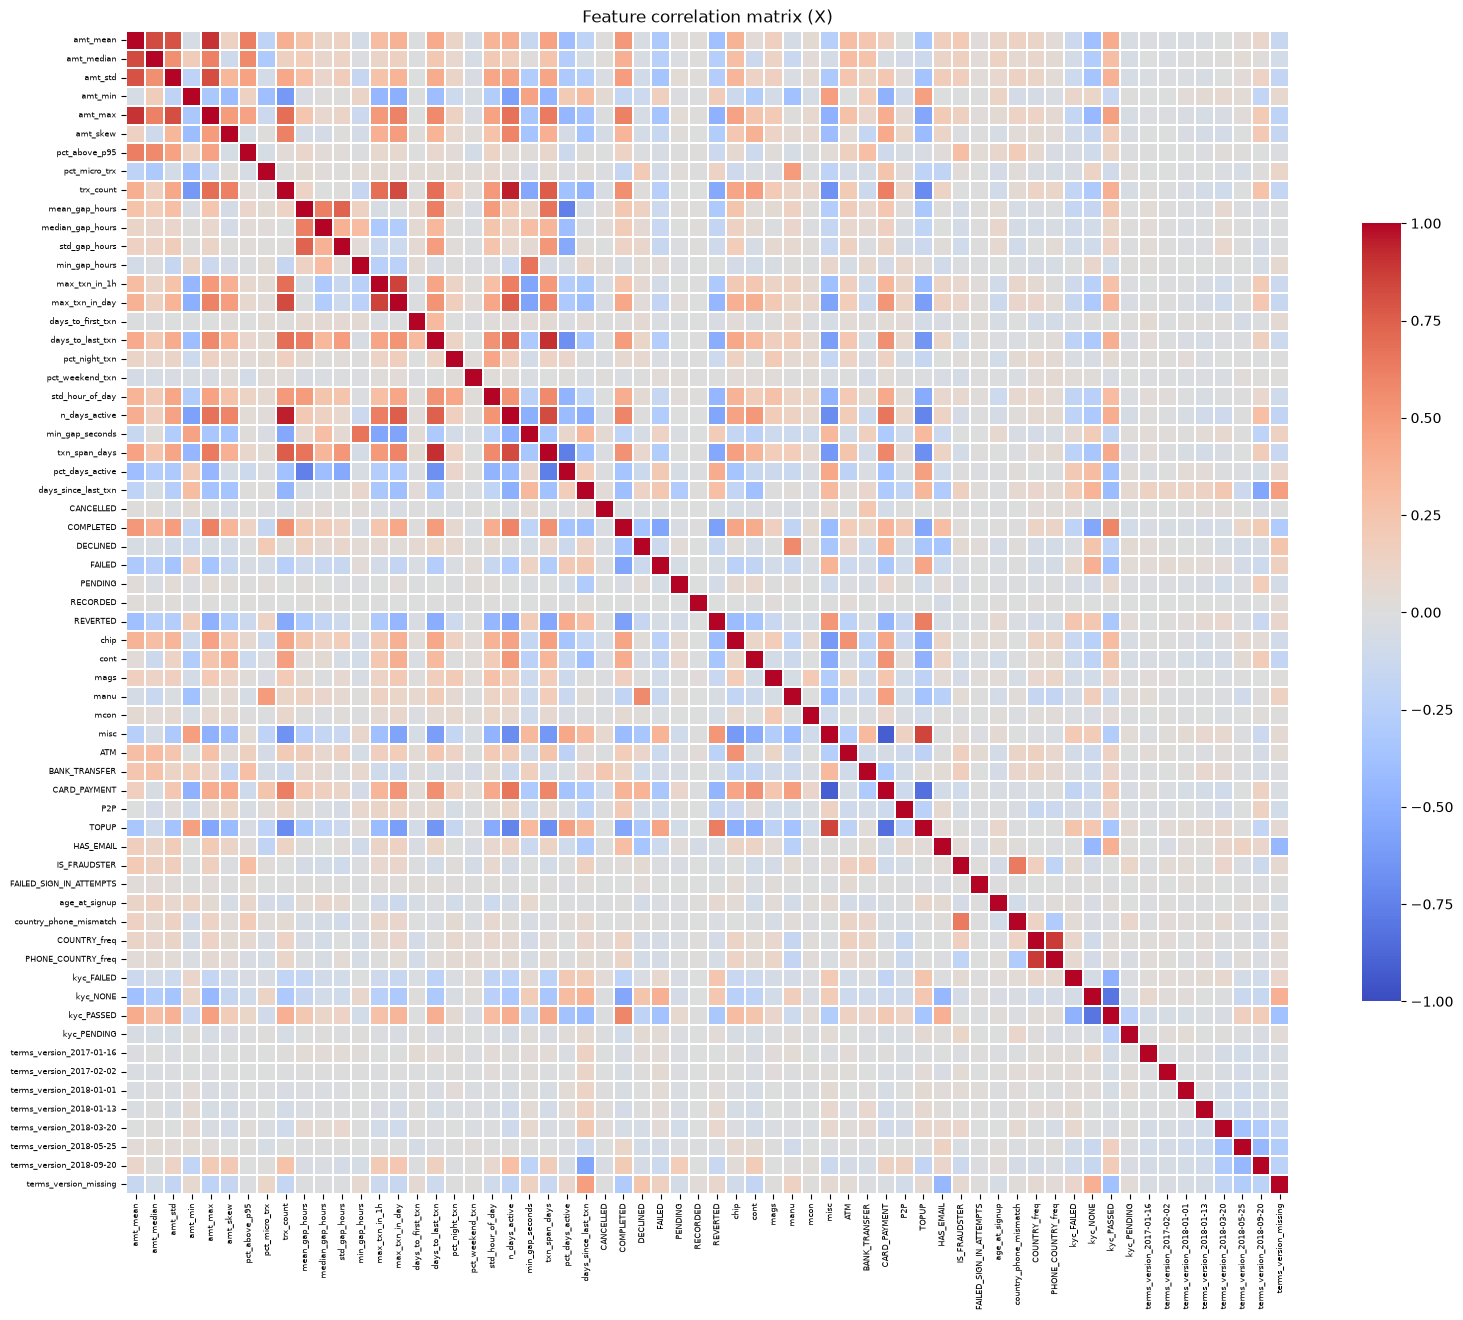

,feature_1,feature_2,correlation,abs_correlation
516,trx_count,n_days_active,0.946668,0.946668
2334,misc,CARD_PAYMENT,-0.920014,0.920014
1014,days_to_last_txn,txn_span_days,0.911448,0.911448
4,amt_mean,amt_max,0.900321,0.900321
3025,COUNTRY_freq,PHONE_COUNTRY_freq,0.882252,0.882252
820,max_txn_in_1h,max_txn_in_day,0.856925,0.856925


In [29]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Feature correlation matrix (X)', fontsize=12, color='#0b0b0b')
ax.tick_params(axis='both', labelsize=6)
plt.tight_layout()
plt.show()

# pairwise correlations above a threshold, upper triangle only (no self-pairs/duplicates)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
               .stack()
               .rename('correlation')
               .reset_index()
               .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
high_corr = corr_pairs.query('abs_correlation > 0.85').sort_values('abs_correlation', ascending=False)
high_corr

### glimpse into data with dimensionality reduction (PCA, t-SNE, SVD)

In [31]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# T-SNE Implementation
%timeit
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)

# PCA Implementation
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)

# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)


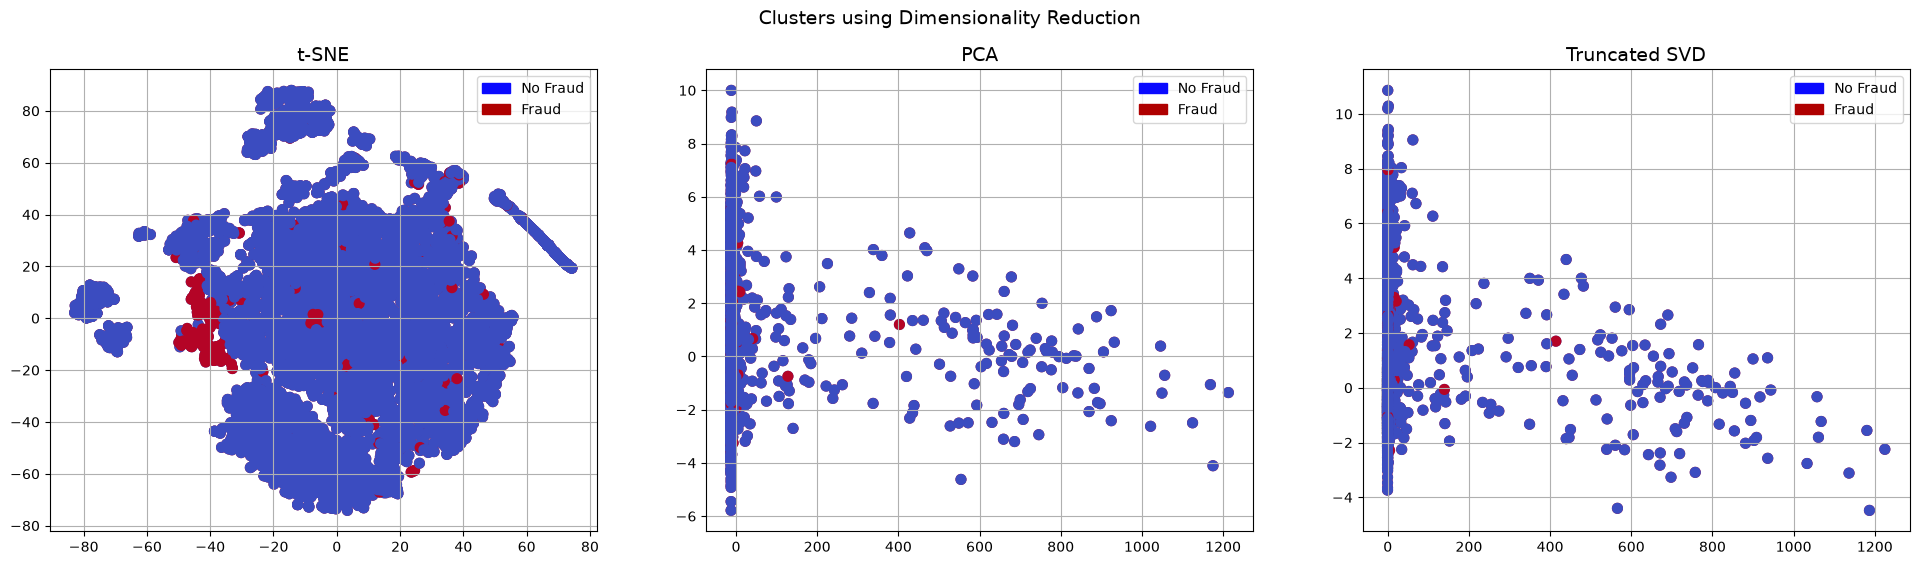

In [33]:
import matplotlib.patches as mpatches
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Not Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

### FIRST MODELS

In [45]:
# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, roc_auc_score

# classification_report, confusion_matrix, 
# roc_auc_score, roc_curve, precision_recall_curve, 
# average_precision_score, 



In [49]:
X = X.drop('IS_FRAUDSTER', axis=1)

In [50]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples ({y_train.sum()} fraudsters, {y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({y_test.sum()} fraudsters, {y_test.sum()/len(y_test)*100:.1f}%)")


Training set: 5748 samples (238 fraudsters, 4.1%)
Test set: 1438 samples (59 fraudsters, 4.1%)


In [51]:
classifiers = {
    "LogisiticRegression": LogisticRegression(max_iter=1000),
    # "Support Vector Classifier": SVC(),
    "KNearest": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=100, max_depth=5)
}

In [ ]:
# for this unbalanced dataset acuracy is quite useless. 
# moreover I coudl assume that for business much worse not to detect fraudested then overdetect. 
# that's why recall here goes as a first metric

In [56]:
for key, classifier in classifiers.items():
    
    classifier.fit(X_train, y_train)
    
    y_pred = classifier.predict(X_test) 
       
    recall = np.round(recall_score(y_test, y_pred)*100, 2)
    precision = np.round(precision_score(y_test, y_pred)*100, 2)
    f1 = np.round(f1_score(y_test, y_pred)*100, 2)
    
    print(f"Classifier - {classifier.__class__.__name__}: recall={recall}%, precision={precision}%, f1-score={f1}%")

Classifier - LogisticRegression: recall=81.36%, precision=88.89%, f1-score=84.96%
Classifier - KNeighborsClassifier: recall=38.98%, precision=95.83%, f1-score=55.42%
Classifier - DecisionTreeClassifier: recall=88.14%, precision=89.66%, f1-score=88.89%
Classifier - RandomForestClassifier: recall=83.05%, precision=98.0%, f1-score=89.91%
Classifier - GradientBoostingClassifier: recall=88.14%, precision=96.3%, f1-score=92.04%


In [59]:
# too good to be true. we have unbalanced data. it could be also some data leakage. let's try first undersampling. 